# Part I - Ford GoBike System Data Exploration
## by Debasis Mishra

## Introduction
> The Ford GoBike System Data dataset contains information about individual bike-sharing trips made in the San Francisco Bay Area during February 2019. The dataset includes ride duration, start and end stations, trip timestamps, user type, rider gender, and birth year. These variables provide an opportunity to investigate rider behavior, usage patterns, trip characteristics, and demographic trends.

> The primary goal of this exploration is to understand how the bike-sharing service is used and identify factors that influence trip behavior. Specifically, this analysis will explore:

> The distribution of trip durations.
The demographics of riders (age and gender).
Differences between Subscribers and Customers.
Peak usage hours and days.
Relationships between rider characteristics and trip duration.

> Insights obtained from this exploratory analysis will be used in Part II to create explanatory visualizations that communicate the most important findings.



## Preliminary Wrangling


In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
%matplotlib inline

# Set plot style
sns.set_style('whitegrid')

In [5]:
# Load Ford GoBike dataset
df = pd.read_csv(
    r'C:\Users\debasis.b.mishra\OneDrive - Accenture\Desktop\Python-Example\Project\201902-fordgobike-tripdata.csv.crdownload'
)
df.head()


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


### What is the structure of your dataset?

> The dataset consists of individual bike-sharing trip records from the Ford GoBike system in the San Francisco Bay Area. Each row represents a single bike trip, while each column contains information about the trip, such as duration, start and end times, station locations, user type, rider gender, and birth year. The dataset contains both numerical and categorical variables, along with datetime features that can be used to analyze usage patterns over time.

### What is/are the main feature(s) of interest in your dataset?

> The main features of interest are trip duration (duration_sec), user type (user_type), and trip usage patterns based on time. These features will help determine how customers and subscribers use the bike-sharing service, how long trips typically last, and when the system experiences the highest demand.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> duration_sec: Measures the length of each trip and helps analyze ride behavior.
user_type: Distinguishes between Customers and Subscribers, allowing comparison of usage patterns.
start_time and end_time: Used to extract hours, days, and other time-based variables to identify peak usage periods.
member_birth_year: Used to calculate rider age and analyze demographic trends.
member_gender: Helps examine differences in usage among gender groups.
start_station_name and end_station_name: Useful for identifying popular stations and travel patterns.

> These variables will help explore rider demographics, trip characteristics, commuting behavior, and differences between user groups.

# Univariate Exploration

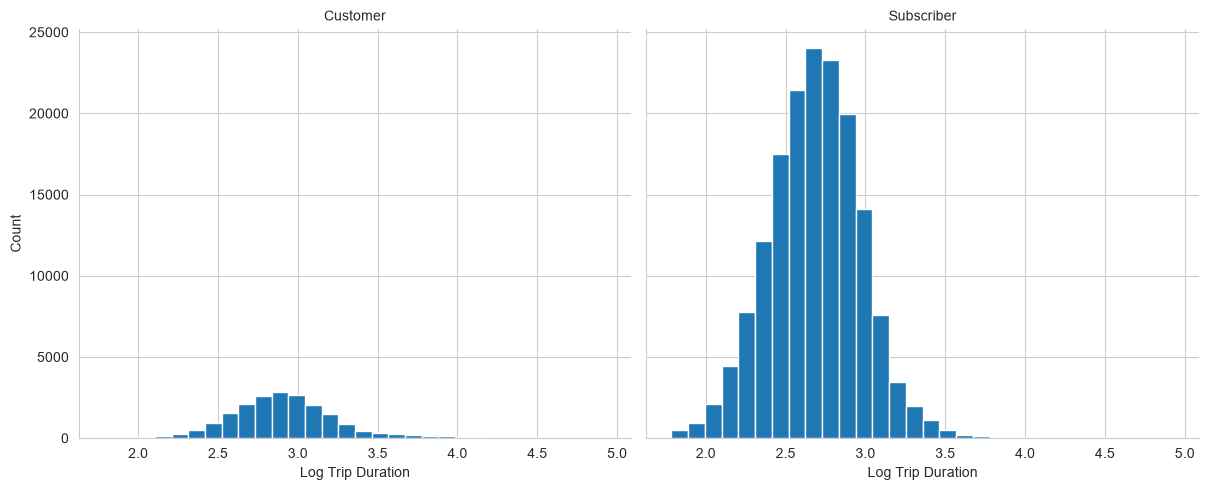

In [7]:
# Facet Plot: Trip Duration by User Type

df['log_duration'] = np.log10(df['duration_sec'])

g = sns.FacetGrid(
    data=df,
    col='user_type',
    height=5,
    aspect=1.2
)

g.map(plt.hist, 'log_duration', bins=30)

g.set_axis_labels('Log Trip Duration', 'Count')
g.set_titles('{col_name}')

plt.show()

## Observation

> The facet plot reveals that Subscribers generally take shorter trips, while Customers have a wider range of trip durations and are more likely to take longer rides. This finding supports the conclusion that Subscribers primarily use the service for commuting, whereas Customers use it more frequently for recreational purposes.

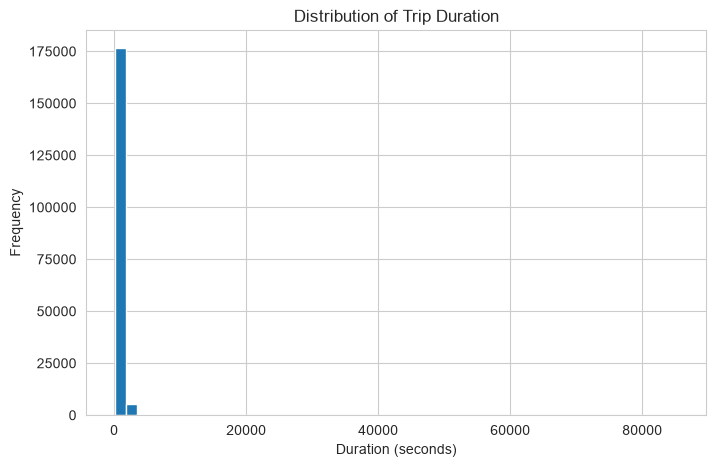

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df['duration_sec'], bins=50)
plt.title('Distribution of Trip Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()


## Observation
> The trip duration distribution is highly right-skewed. Most trips are relatively short, while a small number of trips have exceptionally long durations. This suggests the presence of outliers and indicates that a transformation may be useful for better visualization.

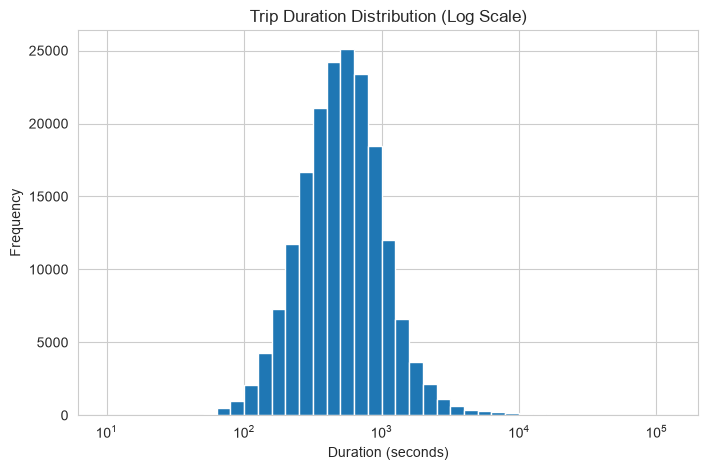

In [20]:
plt.figure(figsize=(8,5))

bins = 10 ** np.arange(1, 5.2, 0.1)

plt.hist(df['duration_sec'], bins=bins)
plt.xscale('log')

plt.title('Trip Duration Distribution (Log Scale)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')

plt.show()

## Observation

> After applying a logarithmic scale, the distribution becomes more interpretable. Most trips appear to last between approximately 5 and 30 minutes.

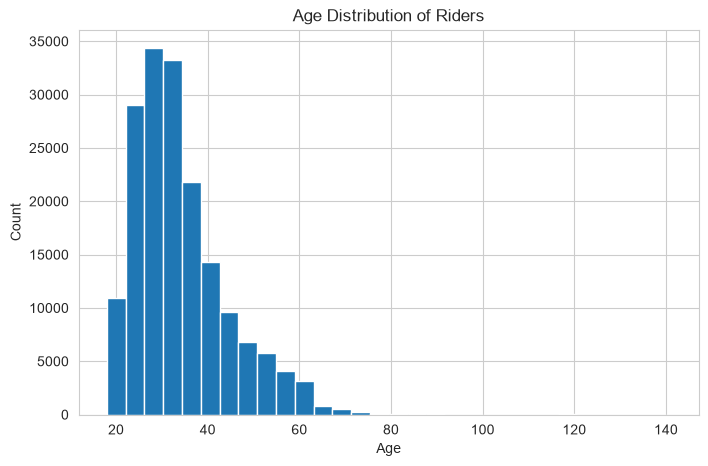

In [8]:
df['age'] = 2019 - df['member_birth_year']
df_age = df.dropna(subset=['age'])

plt.figure(figsize=(8,5))

plt.hist(df_age['age'], bins=30)

plt.title('Age Distribution of Riders')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

## Observation

> Most riders fall between 25 and 40 years of age. There are relatively few riders in older age groups.

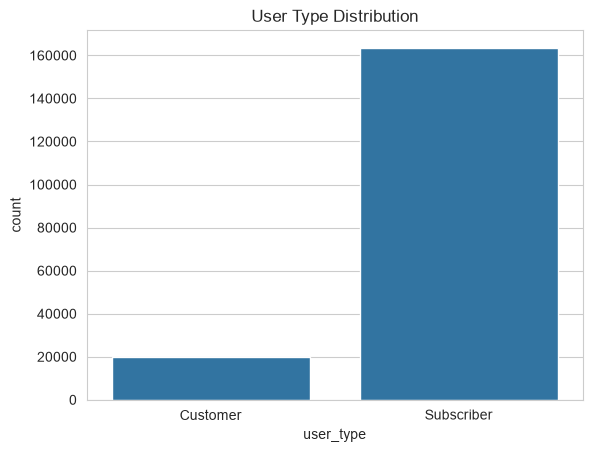

In [25]:
sns.countplot(data=df, x='user_type')

plt.title('User Type Distribution')
plt.show()

## Observation

> Subscribers greatly outnumber Customers, indicating that the service is primarily used by regular members.

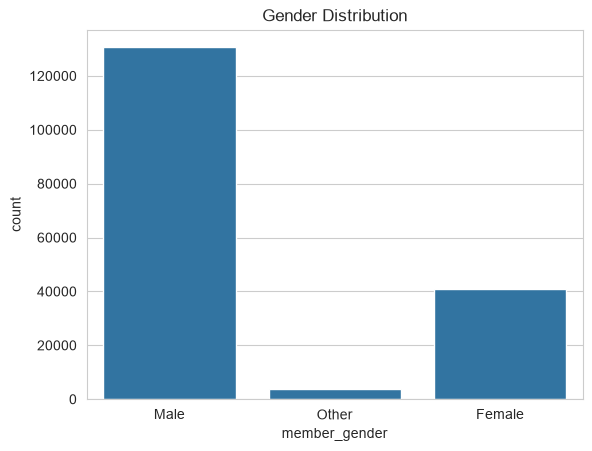

In [26]:
sns.countplot(data=df, x='member_gender')

plt.title('Gender Distribution')
plt.show()

## Observation

> Male riders make up the largest proportion of users, followed by female riders. A small number of records fall under other or missing gender categories.

,start_time,start_hour
0,2019-02-28 17:32:10.145,17
1,2019-02-28 18:53:21.789,18
2,2019-02-28 12:13:13.218,12
3,2019-02-28 17:54:26.010,17
4,2019-02-28 23:54:18.549,23


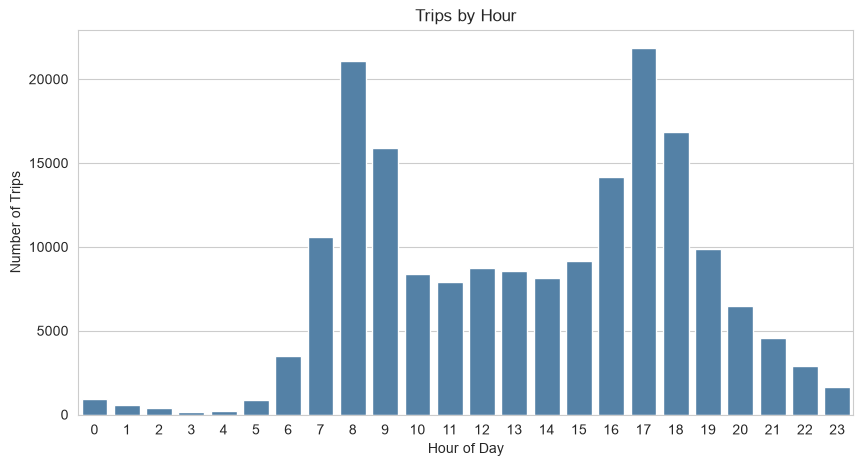

In [4]:
df['start_time'] = pd.to_datetime(df['start_time'])

df['start_hour'] = df['start_time'].dt.hour

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='start_hour',
    color='steelblue'
)

plt.title('Trips by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

df[['start_time', 'start_hour']].head()

## Observation

> Usage peaks during the morning and evening commute hours, suggesting that many riders use the service for transportation to and from work.

               start_time start_day
0 2019-02-28 17:32:10.145  Thursday
1 2019-02-28 18:53:21.789  Thursday
2 2019-02-28 12:13:13.218  Thursday
3 2019-02-28 17:54:26.010  Thursday
4 2019-02-28 23:54:18.549  Thursday


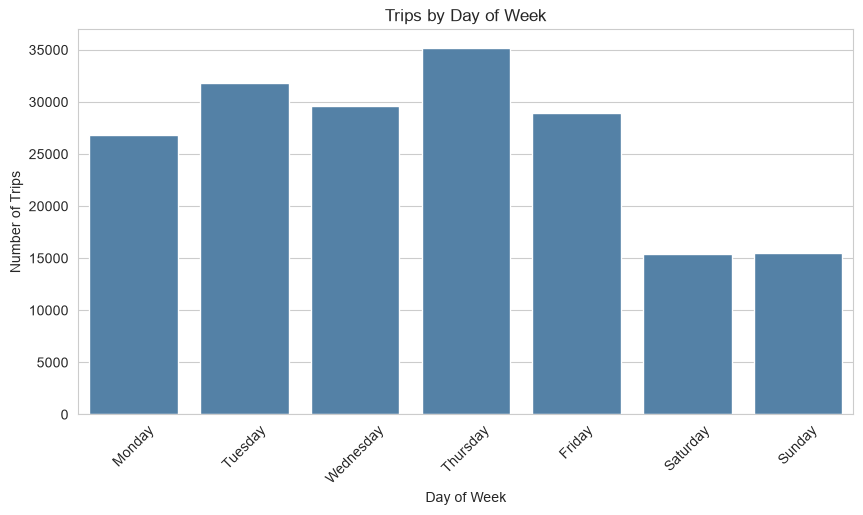

In [7]:
# Ensure start_time is datetime
df['start_time'] = pd.to_datetime(df['start_time'])

# Extract day name
df['start_day'] = df['start_time'].dt.day_name()

print(df[['start_time', 'start_day']].head())



order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='start_day',
    order=order,
    color='steelblue'
)

plt.xticks(rotation=45)
plt.title('Trips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')

plt.show()


## Observation

> Weekday usage is generally higher than weekend usage, indicating that the bike-sharing service is commonly used for commuting purposes.

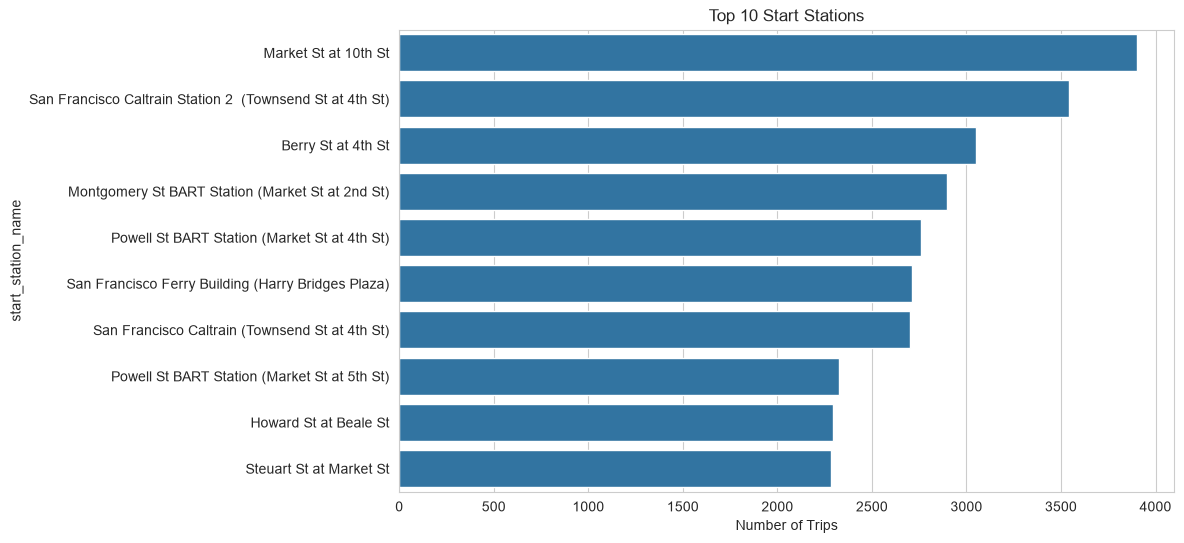

In [8]:
top_start = df['start_station_name'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_start.values,
    y=top_start.index
)

plt.title('Top 10 Start Stations')
plt.xlabel('Number of Trips')

plt.show()

## Observation

> A few stations account for a substantial proportion of trips, indicating concentrated demand in certain areas.

# Summary of Univariate Findings

> Trip duration is highly right-skewed and better analyzed using a log scale.
> Most riders are between 25 and 40 years old.
> Subscribers make up the majority of users.
> Male riders represent the largest user group.
> Bike usage peaks during typical commuting hours.
> Weekday demand exceeds weekend demand.
> A small number of stations account for a large share of trips.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> The primary variables of interest were trip duration, user type, rider age, gender, and trip start time. The distribution of trip duration was highly right-skewed, with most trips lasting a relatively short period and a small number of trips having very long durations. To better visualize the distribution, a logarithmic scale was applied to the trip duration variable. This transformation reduced skewness and made the overall pattern easier to interpret.

> The distribution of rider ages showed that most users were young to middle-aged adults, with the highest concentration between approximately 25 and 40 years old. The user type distribution revealed that Subscribers accounted for the majority of trips, while Customers represented a much smaller portion of users. Trip activity by hour displayed clear peaks during morning and evening commuting hours, indicating that the service is frequently used for commuting purposes.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> Several features required cleaning and transformation before analysis. The start_time and end_time columns were converted to datetime format to enable extraction of useful variables such as hour of day and day of week. A new age variable was created using the rider's birth year.

> Missing values were observed in the member_birth_year column, resulting in missing age values. These records were excluded from age-related analyses. Additionally, some riders had unrealistically high ages, which were treated as outliers and removed to improve the accuracy of the visualizations.

> The trip duration variable exhibited a highly skewed distribution with extreme values. Therefore, a logarithmic transformation was used for some visualizations to better understand the underlying distribution. These data-cleaning and transformation steps helped produce clearer visualizations and more reliable insights for further exploration.

# Bivariate Exploration

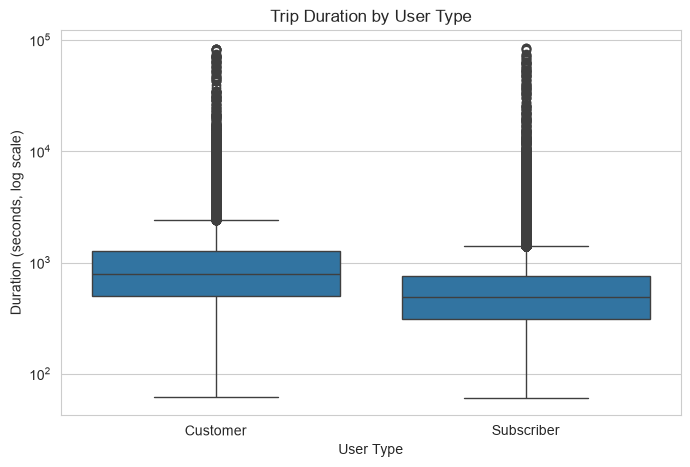

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='user_type',
    y='duration_sec'
)

plt.yscale('log')

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Duration (seconds, log scale)')

plt.show()

## Observation

> Customers generally take longer trips than Subscribers. Subscribers tend to have shorter and more consistent trip durations, which supports the idea that they primarily use the service for commuting. Customers exhibit greater variation in trip duration, suggesting more recreational usage.

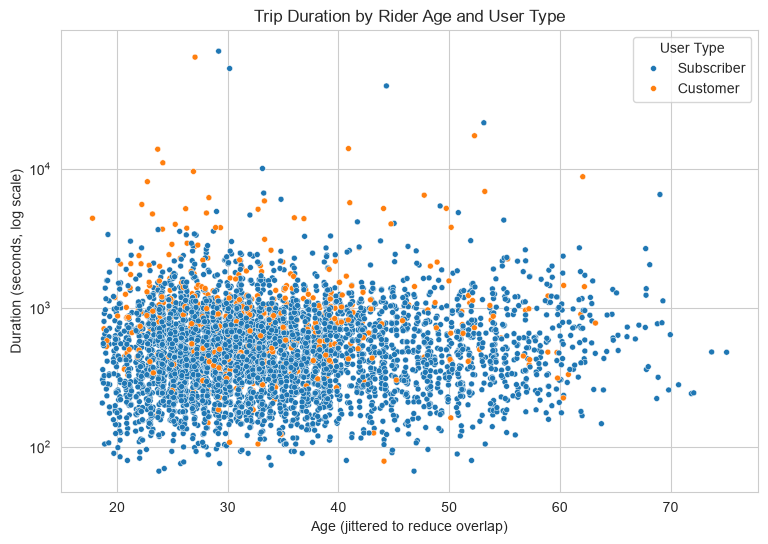

In [9]:
plot_df = df.dropna(subset=['member_birth_year', 'duration_sec', 'user_type']).copy()

plot_df['age'] = 2019 - plot_df['member_birth_year']

plot_df = plot_df.query('18 <= age <= 80').copy()

rng = np.random.default_rng(42)

plot_df['age_jitter'] = plot_df['age'] + rng.uniform(-0.35, 0.35, len(plot_df))

sample_df = plot_df.sample(min(5000, len(plot_df)), random_state=42)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_df,
    x='age_jitter',
    y='duration_sec',
    hue='user_type',
    s=18
)

plt.yscale('log')

plt.title('Trip Duration by Rider Age and User Type')
plt.xlabel('Age (jittered to reduce overlap)')
plt.ylabel('Duration (seconds, log scale)')
plt.legend(title='User Type')

plt.show()

## Observation

> There is no strong relationship between rider age and trip duration. Riders of most age groups tend to take trips of similar lengths, although the majority of users are concentrated between ages 25 and 40.

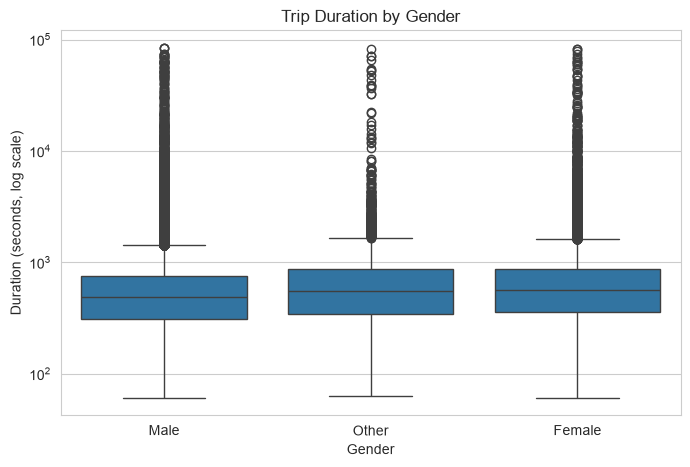

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='member_gender',
    y='duration_sec'
)

plt.yscale('log')

plt.title('Trip Duration by Gender')
plt.xlabel('Gender')
plt.ylabel('Duration (seconds, log scale)')

plt.show()

## Observation

> The trip duration distributions for male and female riders are broadly similar. However, there are some differences in median duration and variability across gender groups.

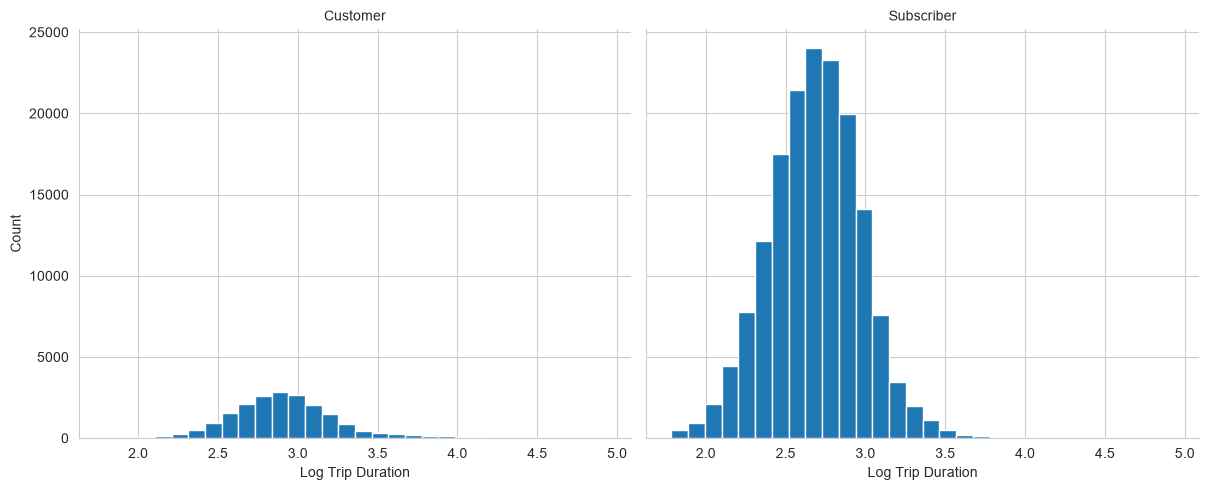

In [16]:
df['log_duration'] = np.log10(df['duration_sec'])

g = sns.FacetGrid(
    data=df,
    col='user_type',
    height=5,
    aspect=1.2
)

g.map(plt.hist, 'log_duration', bins=30)

g.set_axis_labels('Log Trip Duration', 'Count')
g.set_titles('{col_name}')

plt.show()

## Observation

> Subscribers tend to take shorter trips while Customers exhibit a wider range of trip durations and more long rides.

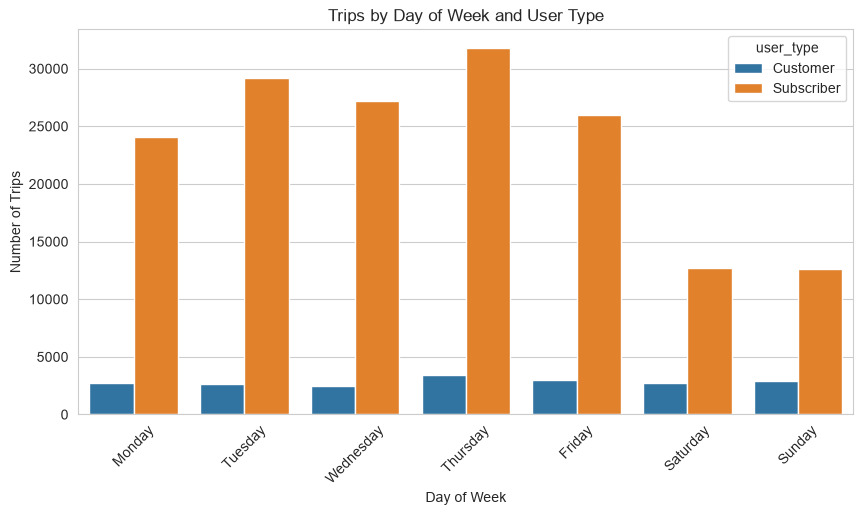

In [13]:
order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='start_day',
    hue='user_type',
    order=order
)

plt.xticks(rotation=45)

plt.title('Trips by Day of Week and User Type')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')

plt.show()

## Observation

> Subscribers dominate usage throughout the week, especially on weekdays. Customers account for a relatively larger proportion of trips during weekends, suggesting recreational use.

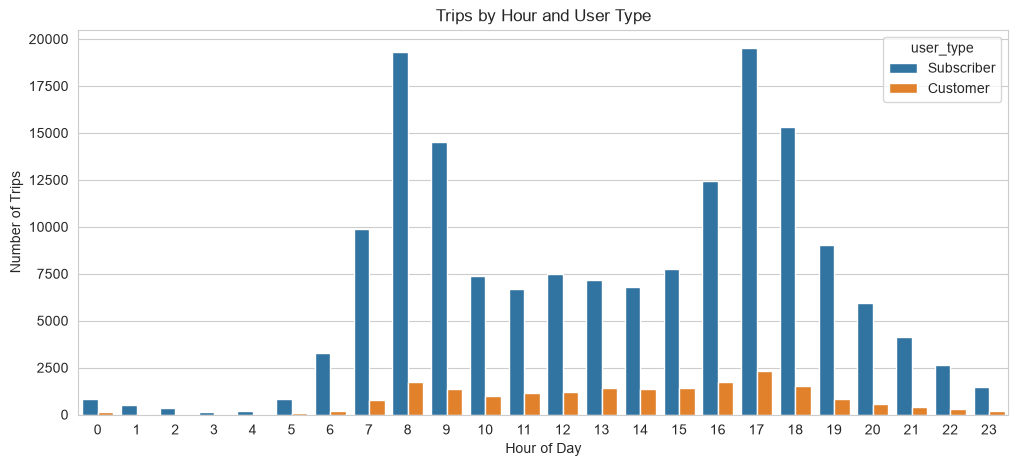

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='start_hour',
    hue='user_type'
)

plt.title('Trips by Hour and User Type')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

plt.show()

## Observation

> Subscribers show clear peaks during morning and evening commuting hours, while Customers exhibit a more evenly distributed usage pattern throughout the day.

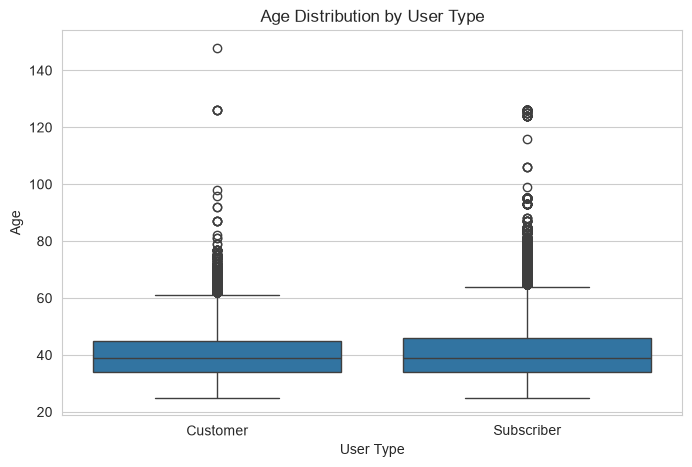

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='user_type',
    y='age'
)

plt.title('Age Distribution by User Type')
plt.xlabel('User Type')
plt.ylabel('Age')

plt.show()

## Observation

> Both Customers and Subscribers are primarily working-age adults. Subscribers appear to have a slightly narrower age range compared to Customers.

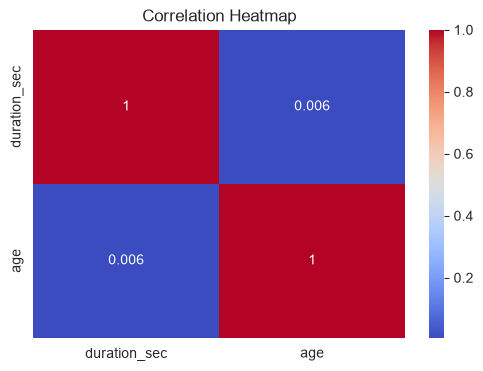

In [10]:
corr = df[['duration_sec', 'age']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

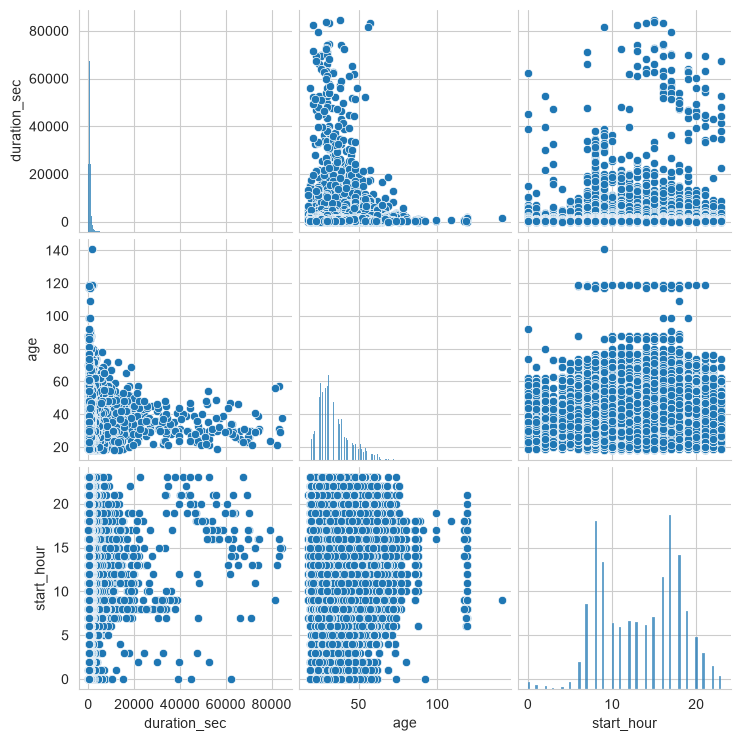

In [13]:
# Convert start_time to datetime
df['start_time'] = pd.to_datetime(df['start_time'])

# Extract hour
df['start_hour'] = df['start_time'].dt.hour

plot_df = df[['duration_sec', 'age', 'start_hour']].dropna()

sns.pairplot(plot_df)

plt.show()

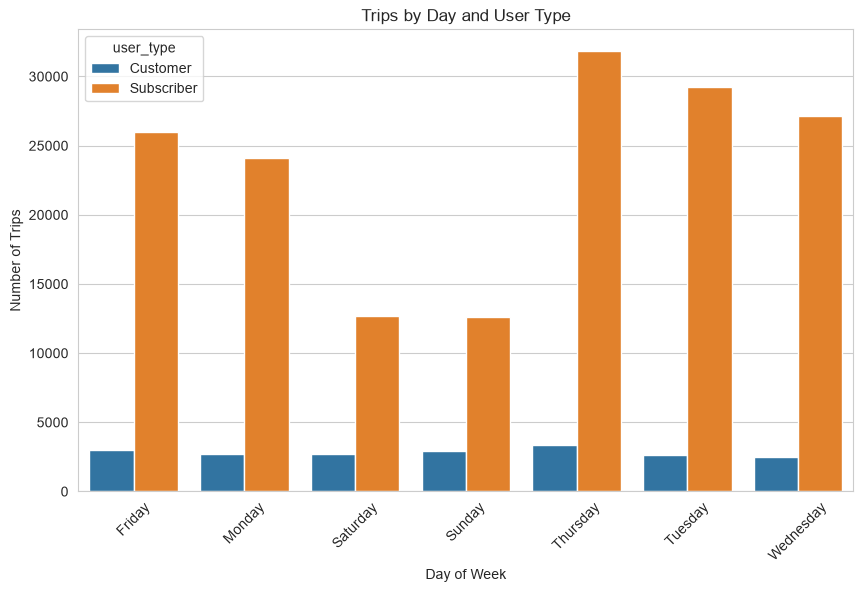

In [14]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['start_day'] = df['start_time'].dt.day_name()

day_user = (
    df.groupby(['start_day', 'user_type'])
      .size()
      .reset_index(name='count')
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=day_user,
    x='start_day',
    y='count',
    hue='user_type'
)

plt.xticks(rotation=45)

plt.title('Trips by Day and User Type')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')

plt.show()

# Summary of Bivariate Findings

> The bivariate analysis revealed several important relationships. Customers generally take longer trips than Subscribers, suggesting different usage purposes. Subscriber activity is concentrated around weekday commuting hours, while Customer activity is more evenly distributed and relatively higher during weekends. Rider age shows only a weak relationship with trip duration, and gender differences in trip duration are relatively small. Overall, the results indicate that Subscribers primarily use the service for transportation, whereas Customers are more likely to use it for leisure and recreational purposes.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Several meaningful relationships were identified during the bivariate exploration. Trip duration showed a noticeable relationship with user type. Customers generally took longer trips than Subscribers, suggesting that Customers are more likely to use the bike-sharing service for leisure or recreational purposes, while Subscribers primarily use it for commuting and other routine transportation needs.

> The analysis of trip activity by hour and user type revealed strong commuting patterns among Subscribers. Subscriber trips peaked during the morning and evening rush hours, whereas Customer trips were more evenly distributed throughout the day.

> Rider age showed only a weak relationship with trip duration. Most riders, regardless of age, tended to take trips of similar duration, although the majority of users were concentrated within the 25 to 40 age range. Similarly, gender did not appear to have a major impact on trip duration, as the distributions for male and female riders were relatively similar.

> Overall, the most significant relationships observed involved user type and time-related features, indicating that riding behavior varies considerably between Subscribers and Customers.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Yes. One interesting relationship was observed between day of the week and user type. Subscriber usage was consistently higher during weekdays, particularly from Monday through Friday, which further supports the interpretation that Subscribers use the system for work-related commuting. In contrast, Customers represented a larger proportion of trips during weekends.

> Another notable relationship was between hour of the day and trip frequency. Trip counts increased substantially during morning and evening commuting periods and decreased during late-night hours. This pattern suggests that the bike-sharing service plays an important role in daily transportation within the San Francisco Bay Area.

> Additionally, the age distributions of Customers and Subscribers were broadly similar, indicating that both user groups are primarily composed of working-age adults. However, Subscribers appeared to have a slightly more concentrated age range compared to Customers.

> These relationships provide valuable context for the multivariate exploration, where multiple variables can be analyzed simultaneously to gain deeper insights into rider behavior and usage patterns.

> Provide your feedback on BizChat

## Multivariate Exploration

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

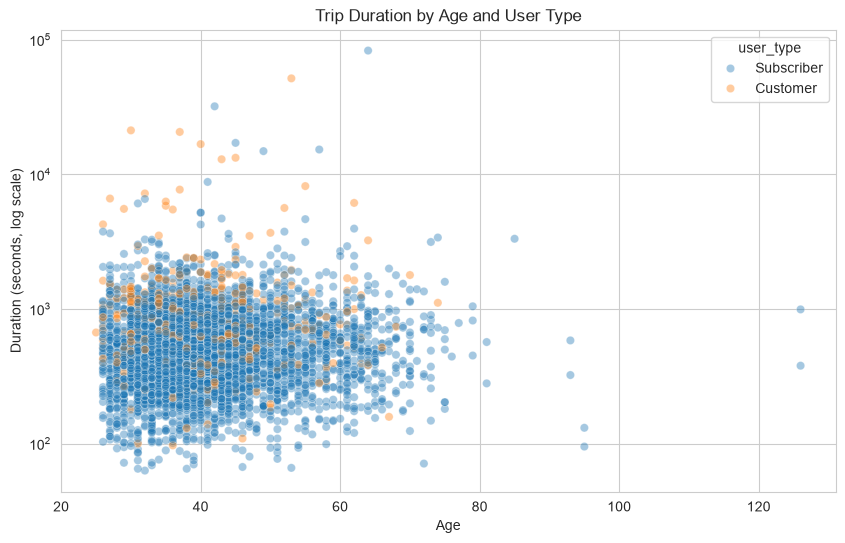

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x='age',
    y='duration_sec',
    hue='user_type',
    alpha=0.4
)

plt.yscale('log')

plt.title('Trip Duration by Age and User Type')
plt.xlabel('Age')
plt.ylabel('Duration (seconds, log scale)')

plt.show()

## Observation

> Subscriber trips tend to cluster around shorter durations across most age groups. Customers generally exhibit longer trip durations and greater variability. Age does not appear to strongly influence trip duration for either user group.

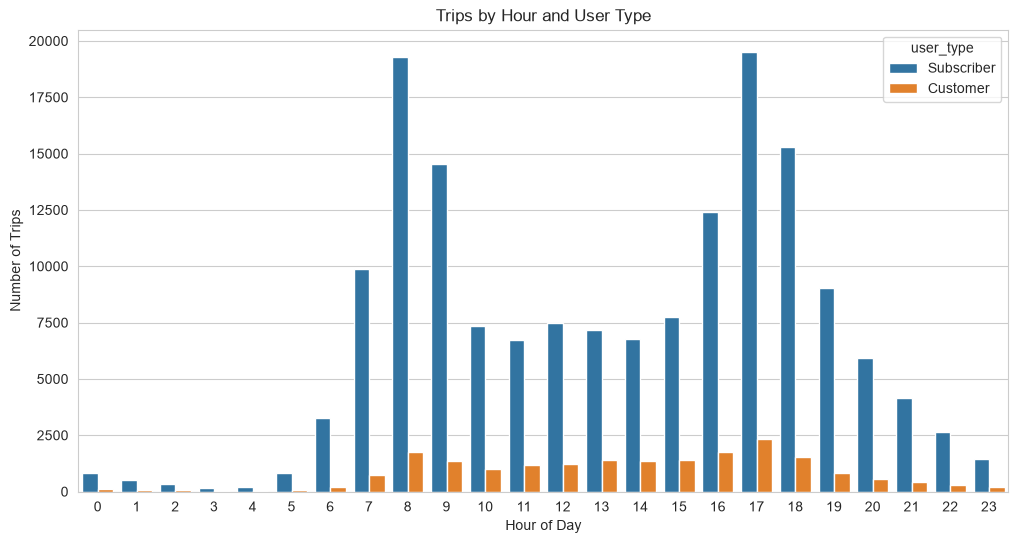

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='start_hour',
    hue='user_type'
)

plt.title('Trips by Hour and User Type')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

plt.show()

## Observation

> Subscribers show pronounced peaks during commuting hours (around 8 AM and 5 PM), while Customers display more evenly distributed activity throughout the day. This suggests that Subscribers primarily use the service for work-related travel.

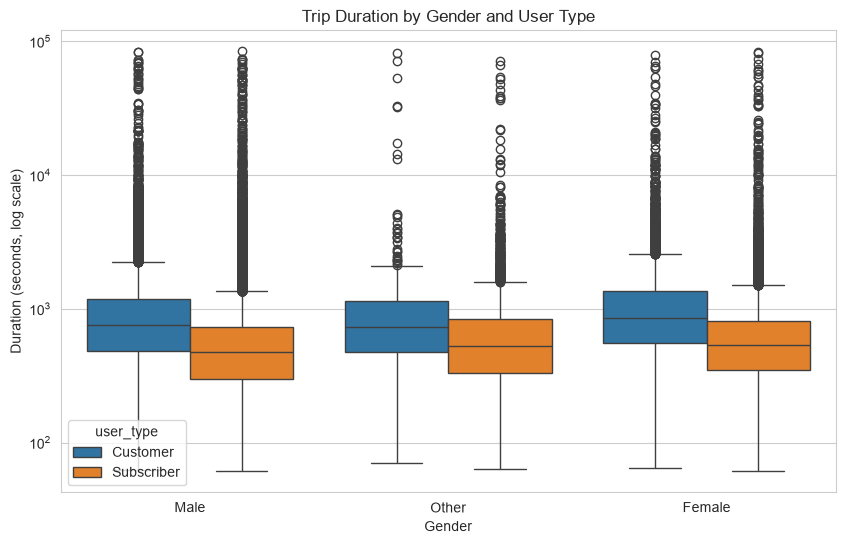

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='member_gender',
    y='duration_sec',
    hue='user_type'
)

plt.yscale('log')

plt.title('Trip Duration by Gender and User Type')
plt.xlabel('Gender')
plt.ylabel('Duration (seconds, log scale)')

plt.show()

## Observation

> Across all gender groups, Customers generally take longer trips than Subscribers. The overall pattern remains consistent regardless of gender, indicating that user type has a stronger effect on trip duration than gender.

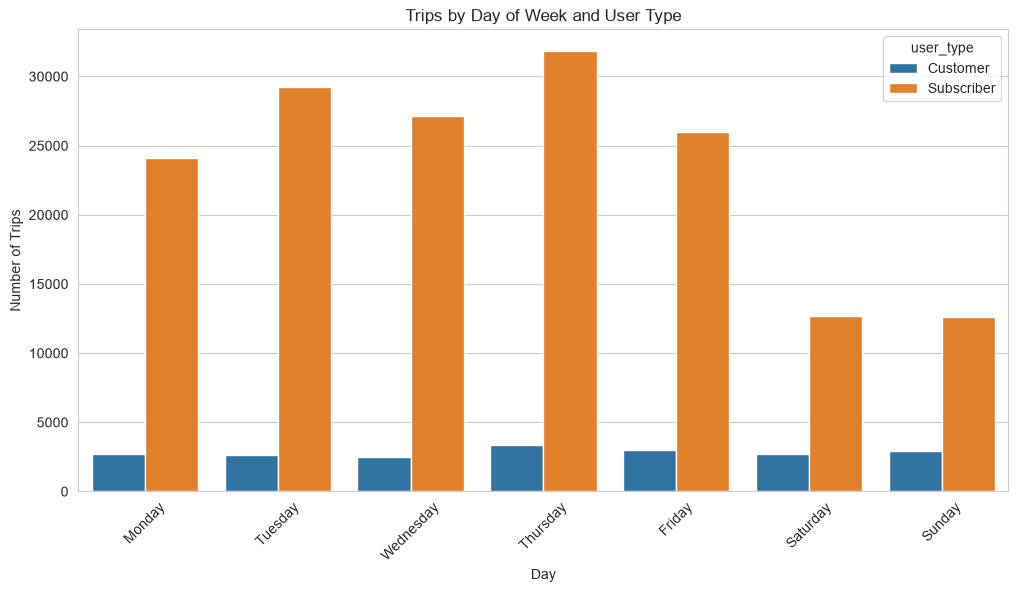

In [19]:
order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='start_day',
    hue='user_type',
    order=order
)

plt.xticks(rotation=45)

plt.title('Trips by Day of Week and User Type')
plt.xlabel('Day')
plt.ylabel('Number of Trips')

plt.show()

## Observation

> Subscribers dominate weekday usage, while Customers account for a relatively larger share of weekend trips. This reinforces the distinction between commuting and leisure-oriented usage patterns.

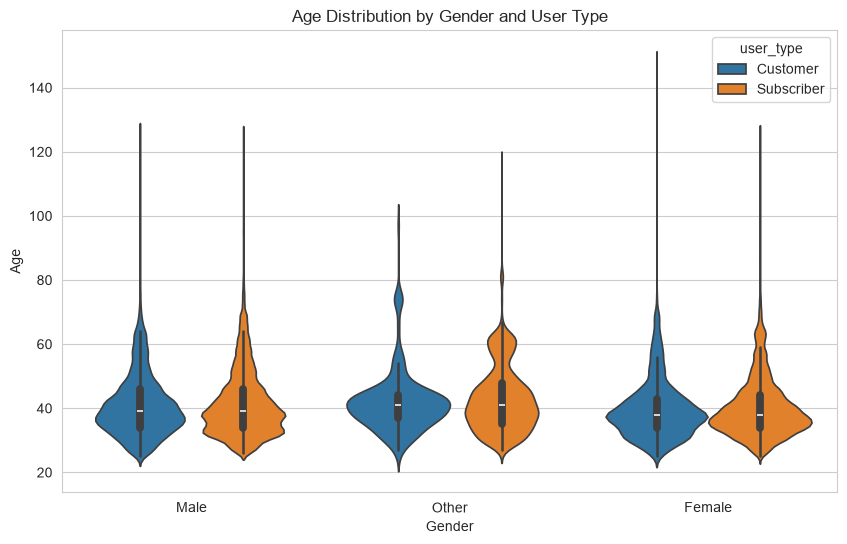

In [20]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='member_gender',
    y='age',
    hue='user_type',
    split=False
)

plt.title('Age Distribution by Gender and User Type')
plt.xlabel('Gender')
plt.ylabel('Age')

plt.show()

## Observation

> Most riders are concentrated between 25 and 40 years old regardless of gender or user type. Subscriber age distributions tend to be slightly more concentrated than Customer distributions.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> The multivariate analysis reinforced several patterns discovered during the univariate and bivariate explorations. User type remained the strongest factor influencing trip behavior. When trip duration, age, and user type were analyzed together, Subscribers consistently showed shorter trip durations across most age groups, while Customers tended to take longer trips. This strengthened the finding that Subscribers primarily use the bike-sharing service for commuting, whereas Customers are more likely to use it for leisure and recreational travel.

> Time-related variables also strengthened one another. When examining trip frequency by both hour of day and user type, Subscriber trips showed clear peaks during morning and evening commuting hours. Additionally, combining day of week and user type revealed that Subscribers were much more active on weekdays, while Customers contributed a larger share of trips during weekends. Together, these patterns provide strong evidence that the service is heavily used for daily transportation by Subscribers.

> The combination of age, gender, and user type showed that demographic factors had a smaller influence on riding behavior compared to user type. Regardless of age or gender, the differences between Customers and Subscribers remained consistent, highlighting user type as the primary driver of trip characteristics.

### Were there any interesting or surprising interactions between features?

> One interesting finding was that age appeared to have very little influence on trip duration. Although riders ranged across various age groups, most users exhibited similar riding patterns regardless of age. This was somewhat surprising because it was expected that younger riders might take noticeably longer trips.

> Another notable interaction was the consistency of commuting behavior among Subscribers. The combination of user type, day of week, and hour of day revealed a very strong commuter pattern, with peak activity occurring during traditional workday hours and weekdays. In contrast, Customer trips were more evenly distributed throughout the day and week.

> It was also interesting to observe that gender did not substantially change the relationship between user type and trip duration. Across all gender groups, Customers generally took longer trips than Subscribers, suggesting that riding purpose has a greater impact on trip duration than demographic characteristics.

> Overall, the multivariate analysis confirmed that user type is the most influential feature in the dataset and plays a key role in explaining differences in trip duration, trip timing, and overall rider behavior.

## Conclusions
> This exploratory analysis examined the Ford GoBike System Data dataset to better understand rider behavior, trip characteristics, and usage patterns within the bike-sharing system. The investigation focused on trip duration, user demographics, user types, and temporal usage trends.

> The univariate analysis revealed that trip durations are highly right-skewed, with most rides being relatively short. A logarithmic transformation was useful for visualizing the distribution more effectively. The rider population was predominantly composed of young to middle-aged adults, and Subscribers represented the majority of users. Bike usage was concentrated during weekday commuting hours, particularly in the morning and evening.

> The bivariate analysis showed that Customers generally took longer trips than Subscribers, suggesting different usage purposes. Subscribers appeared to use the service mainly for transportation and commuting, while Customers were more likely to use it for leisure or recreational activities. Rider age showed only a weak relationship with trip duration, while gender had a relatively limited impact on usage behavior.

> The multivariate analysis reinforced these findings by demonstrating that user type was the most influential factor affecting riding patterns. Subscriber trips were strongly concentrated during weekday rush hours, whereas Customer trips were more evenly distributed across hours and days of the week. Combining demographic and temporal variables further confirmed that commuting behavior is a defining characteristic of Subscriber usage.

> Several data preparation steps were required before analysis. These included converting date fields to datetime format, creating additional features such as rider age, trip hour, and day of the week, handling missing values, and filtering unrealistic age values. These transformations improved the quality of the analysis and allowed for more meaningful visualizations.

> Overall, the analysis suggests that the Ford GoBike system serves two distinct user groups. Subscribers primarily rely on the service for regular commuting, while Customers tend to use the bikes for longer and more recreational trips. Understanding these patterns can help bike-sharing operators improve service planning, optimize resource allocation, and better meet the needs of different rider segments.

> The findings from this exploratory analysis provide a strong foundation for the explanatory visualization phase, where the most significant insights will be communicated through focused and polished visualizations
